In [5]:
from PipingSystem import PipingSystem
from Elements.Coil import Coil
from Elements.Shell import Shell
from Elements.Singularities import SingularityLoss
from Elements.Tube import Tube
import CoolProp.CoolProp as cp
import Pumps.ZX115.ZX115PumpFit as ZX115
import Pumps.Lauda.LaudaPumpFit as LAUDA
import numpy as np
import ht 
import pprint

Definimos el coil y el shell

In [19]:
coil = Coil(d_in = 5.15e-3, d_out=6.35e-3, lenght=1, orientation=-90, material="copper", vueltas = 10, pitch=6.35e-3)
shell = Shell(d_in = 80e-3, d_out=84e-3, lenght =95e-3, orientation=-90, material = "PVC", contain=coil)
print(coil.altura, coil.projected_d_out, coil.curvature_d/2)
print(shell.lenght, shell.d_in, shell.d_hidraulico)

0.6130550986842106 0.003081551030835331
0.0635 0.038116748543027816 0.015947679301376885
0.095 0.08 0.019247998967208885


Definimos el sistema

In [7]:
wfluxsys = PipingSystem()
wfluxsys.add_tube(Tube(d_in = 9.5e-3, d_out = 12.5e-3, lenght=7.5e-2, orientation=0, material="Plastic")) # Derecha
wfluxsys.add_singularity_loss(SingularityLoss(0.9)) # Giro abajo
wfluxsys.add_tube(Tube(d_in = 9.5e-3, d_out = 12.5e-3, lenght=27.5e-3, orientation=-90, material="Plastic")) # Bajo
wfluxsys.add_singularity_loss(SingularityLoss(0.5)) # Cambio de diametro
wfluxsys.add_coil(shell)
wfluxsys.add_singularity_loss(SingularityLoss(0.5)) # Cambio de diametro
wfluxsys.add_tube(Tube(d_in = 9.5e-3, d_out = 12.5e-3, lenght=27.5e-3, orientation=-90, material="Plastic")) # Bajo
wfluxsys.add_singularity_loss(SingularityLoss(0.9)) # Giro izquierda
wfluxsys.add_tube(Tube(d_in = 9.5e-3, d_out = 12.5e-3, lenght=15e-2, orientation=0, material="Plastic")) # Izquierda
wfluxsys.add_singularity_loss(SingularityLoss(0.5)) # Cambio de diametro
wfluxsys.add_tube(Tube(d_in = 9.5e-3, d_out = 12.5e-3, lenght=150e-3, orientation=90, material="Plastic")) # Subo por el tubo
wfluxsys.add_singularity_loss(SingularityLoss(0.9)) # Giro a la derecha
wfluxsys.add_tube(Tube(d_in = 9.5e-3, d_out = 12.5e-3, lenght=7.5e-2, orientation=0, material="Plastic")) # Derecha
wfluxsys.conect() # Conecto

In [8]:
w_volume = wfluxsys.get_volume()
w_volume

0.00032854285097389934

In [9]:
lfluxsys = PipingSystem()
lfluxsys.add_tube(Tube(d_in = 9e-3, d_out = 11e-3, lenght=1.5, orientation=0, material="Plastic")) # Primera manguera del lauda
lfluxsys.add_singularity_loss(SingularityLoss(0.5)) # Primer cambio de diametro
lfluxsys.add_shell(coil) # Serpentin
lfluxsys.add_singularity_loss(SingularityLoss(0.5)) # Segundo cambio de diamtro
lfluxsys.add_tube(Tube(d_in = 9e-3, d_out = 11e-3, lenght=1.5, orientation=0, material="Plastic")) # Segunda manguera del lauda
lfluxsys.conect() # Conectar

Definimos el fluido

In [10]:
tw = 273.15 + 15
pw = 101325        
fluidow = 'Water'  
rhow = cp.PropsSI('D', 'T', tw, 'P', pw, "water")
muw = cp.PropsSI('V', 'T', tw, 'P', pw, "water") 
prw = cp.PropsSI('PRANDTL', 'T', tw, 'P', pw, "water")
kw = cp.PropsSI('CONDUCTIVITY', 'T', tw, 'P', pw, "water")
cpw = cp.PropsSI('CPMASS', 'T', tw, 'P', pw, "water")

In [11]:
tl = 273.15 + 1
pl = 101325        
mul = 0.003 # Pa*s
rhol = 987.14 # kg/m3
cpl = 4267 # J /(kg K)
kl = 0.4984 # W/(m K)
prl = mul*cpl/kl


In [12]:
wfluxsys.cross_system_pump(rhow, muw, ZX115.Pa4m3s, Q_guess=1.2e-5, verbose=True, open = False);
lfluxsys.cross_system_pump(rhol, mul, LAUDA.Pa4m3s, Q_guess=15e-5, verbose=True, open = False);


═════════════════════════════════════════════
        UNTO DE OPERACIÓN DEL SISTEMA        
═════════════════════════════════════════════
 Caudal volumétrico :    1.225 L/min
 Caudal volumétrico      : 2.04e-05 m³/s
 Presión de cruce   :    279.8 Pa
 Pérdida de altura  :    0.029 m.c.a.
═════════════════════════════════════════════


═════════════════════════════════════════════
        UNTO DE OPERACIÓN DEL SISTEMA        
═════════════════════════════════════════════
 Caudal volumétrico :    1.631 L/min
 Caudal volumétrico      : 2.72e-05 m³/s
 Presión de cruce   :  18244.2 Pa
 Pérdida de altura  :    1.884 m.c.a.
═════════════════════════════════════════════



In [13]:
m_dot_water = 2e-05*rhow
m_dot_lauda = 2.95e-05 *rhol

h_coil = coil.get_ht(pr=prw,pr_w=prw,mu=muw,mu_w=muw, k=kw)
h_shell = shell.get_ht(pr=prl,mu=mul,mu_w=mul, k=kl)
k_coil = coil.conductivity 

UA = 1/(1/(h_coil*coil.area_in) + 1/(h_shell*coil.area_out) + np.log(coil.d_out/coil.d_in)/(coil.lenght*2*np.pi*k_coil))

th_in = 20 # 
tc_in = 1 # 

Cmin = ht.calc_Cmin(mh = m_dot_water, mc= m_dot_lauda, Cph = cpw, Cpc= cpl)
Cmin = ht.calc_Cmax(mh = m_dot_water, mc= m_dot_lauda, Cph = cpw, Cpc= cpl)
Cr = ht.calc_Cr(mh = m_dot_water, mc= m_dot_lauda, Cph = cpw, Cpc= cpl)
NTU = ht.NTU_from_UA(UA=UA, Cmin=Cmin)


In [14]:
print(h_coil,h_shell,k_coil)

5209.647260669937 108.22264469895259 380.0


In [15]:
eff = ht.effectiveness_from_NTU(NTU = NTU, Cr=Cr, subtype= "crossflow, mixed Cmax")
print(eff*100)

1.6700416996344658


In [16]:
Q_dot = eff*Cmin*(th_in - tc_in)
tc_out = tc_in + Q_dot/(m_dot_lauda*cpl)
th_out = th_in - Q_dot/(m_dot_water*cpw)

print(Q_dot, tc_out, th_out)


39.42796164638372 1.3173079229305484 19.52890359027004


0.00032854285097389934
17.759073025616182


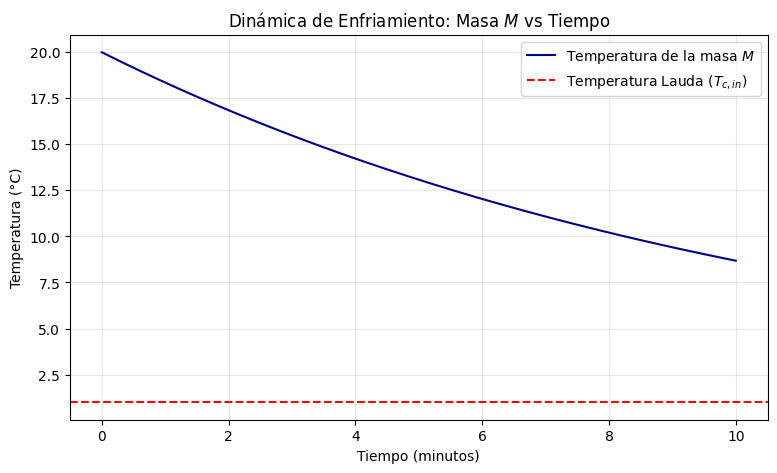

In [17]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def modelo_enfriamiento(t, T, eff, Cmin, M, cpm, tc_in):
    Q_dot = eff * Cmin * (T - tc_in)
    dTdt = -Q_dot / (M * cpm)
    return dTdt

# --- Simulación ---
T0 = [20.0]
t_span = (0, 600)    # 1 hora de simulación
t_eval = np.linspace(0, 600, 600)

sol = solve_ivp(
    modelo_enfriamiento, 
    t_span, 
    T0, 
    args=(eff, Cmin, w_volume*rhow, cpw, tc_in), 
    t_eval=t_eval
)
print(w_volume)
print(w_volume/1.85e-05)

# --- Gráfica ---
plt.figure(figsize=(9, 5))
plt.plot(sol.t / 60, sol.y[0], color='darkblue', label='Temperatura de la masa $M$')
plt.axhline(y=tc_in, color='red', linestyle='--', label='Temperatura Lauda ($T_{c,in}$)')
plt.title('Dinámica de Enfriamiento: Masa $M$ vs Tiempo')
plt.xlabel('Tiempo (minutos)')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()